# Regression Decision Trees & Ensemble Classifier

---
## Import Libraries

In [1]:
# Import pandas for data loading and manipulation
import pandas as pd

# Import numpy for numerical computations
import numpy as np

# Import matplotlib and seaborn for visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Import train_test_split to divide data into training and test subsets
from sklearn.model_selection import train_test_split

# Import Decision Tree Regressor for predicting Maximum Loan Amount
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Import regression evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Import Naive Bayes, Logistic Regression, and KNN for ensemble classifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Import VotingClassifier to combine base learners into an ensemble
from sklearn.ensemble import VotingClassifier

# Import StandardScaler for feature normalisation
from sklearn.preprocessing import StandardScaler

# Import classification metrics for ensemble evaluation
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Set random seed for reproducibility across all models
SEED = 42

# PART A: Loan Approval Status — Ensemble Voting Classifier
## Load Classification Dataset

In [ ]:
# Load the cleaned classification dataset produced in "data_preprocessing" Notebook
df_cls = pd.read_csv('cleaned_classification_data.csv')

# Display shape and first few rows to confirm correct loading
print('Classification Dataset Shape:', df_cls.shape)
df_cls.head()

Classification Dataset Shape: (58632, 11)


,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0
1,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0
2,40.0,131004,MORTGAGE,9,VENTURE,30000,7.90,0.23,N,13,0
3,40.0,150000,MORTGAGE,9,DEBTCONSOLIDATION,25000,11.89,0.17,N,11,0
4,40.0,132000,MORTGAGE,3,HOMEIMPROVEMENT,25000,16.82,0.22,N,17,0


## Prepare Features and Target for Classification


In [3]:
# Separate features (X) from the target variable (y)
X_cls = df_cls.drop(columns=['loan_approval_status'])

# The target variable is 'loan_approval_status' (0=Rejected, 1=Approved).
y_cls = df_cls['loan_approval_status']

# Identifying and encoding any remaining categorical (text) columns before scaling.
categorical_cols_cls = X_cls.select_dtypes(include=['object']).columns.tolist()
print('Categorical columns detected (classification):', categorical_cols_cls)
X_cls = pd.get_dummies(X_cls, columns=categorical_cols_cls, drop_first=True)

# Scale the features using StandardScaler for distance-sensitive algorithms
scaler_cls = StandardScaler()
X_cls_scaled = scaler_cls.fit_transform(X_cls)

# Split data 80/20 with stratification and a fixed random seed for reproducibility.
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls_scaled, y_cls,
    test_size=0.20,
    random_state=SEED,
    stratify=y_cls
)

# Confirm split sizes
print('Training set size:', X_train_c.shape)
print('Test set size:', X_test_c.shape)

Categorical columns detected (classification): ['home_ownership', 'loan_intent', 'payment_default_on_file']
Training set size: (46905, 16)
Test set size: (11727, 16)


## Define Helper Function and Evaluate Individual Base Learners (LR and NB)

We combine **Logistic Regression (LR)** and **Naïve Bayes (NB)** as the two best-performing base learners from "classification_models" Notebook.

In [4]:
# Define a helper function to evaluate classifier models.
def evaluate_classifier(model, X_test, y_test, model_name):
    # Generate class predictions from the trained model
    y_pred = model.predict(X_test)
    # Generate probability predictions for AUC-ROC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    # Calculate recall focusing on the Rejected class (0) as per success criteria
    rec = recall_score(y_test, y_pred, pos_label=0)
    # Calculate precision focusing on the Rejected class (0)
    prec = precision_score(y_test, y_pred, pos_label=0)
    # Calculate F1 score focusing on the Rejected class (0)
    f1 = f1_score(y_test, y_pred, pos_label=0)
    # Calculate Area Under the ROC Curve (AUC).
    auc = roc_auc_score(y_test, y_prob)

    # Print a clear header for the model's evaluation.
    print(f'\n========== {model_name} ==========')
    # Print the calculated evaluation metrics.
    print(f'Accuracy: {acc:.4f} | Recall: {rec:.4f} | Precision: {prec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}')
    # Print the full classification report
    print(classification_report(y_test, y_pred, target_names=['Rejected (0)', 'Approved (1)']))

    # Generate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    # Create a figure with two side-by-side subplots for visualizations.
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Plot the confusion matrix as a heatmap on the first subplot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
    # Set the title for the confusion matrix
    axes[0].set_title(f'{model_name} — Confusion Matrix')
    # Set the x-axis label
    axes[0].set_xlabel('Predicted')
    # Set the y-axis label
    axes[0].set_ylabel('True')

    # Calculate false positive and true positive rates for the ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1)
    # Plot the ROC curve on the second subplot
    axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc:.4f}')
    # Plot the diagonal baseline representing random guessing for ROC
    axes[1].plot([0,1],[0,1],'--', color='navy')
    # Set the title for the ROC curve
    axes[1].set_title(f'{model_name} — AUC-ROC Curve')
    # Set the x-axis label
    axes[1].set_xlabel('FPR')
    # Set the y-axis label
    axes[1].set_ylabel('TPR')
    # Add a legend to display the AUC score
    axes[1].legend(loc='lower right')

    # Adjust layout to prevent overlap
    plt.tight_layout()
    # Display the plots
    plt.show()

    # Return a dictionary of the evaluation results for a summary table
    return {'model': model_name, 'accuracy': acc, 'recall': rec, 'precision': prec, 'f1': f1, 'auc': auc}


========== Base Learner 1 - Logistic Regression ==========
Accuracy: 0.8955 | Recall: 0.9750 | Precision: 0.9096 | F1: 0.9412 | AUC: 0.8839
              precision    recall  f1-score   support

Rejected (0)       0.91      0.98      0.94     10057
Approved (1)       0.73      0.42      0.53      1670

    accuracy                           0.90     11727
   macro avg       0.82      0.70      0.74     11727
weighted avg       0.88      0.90      0.88     11727



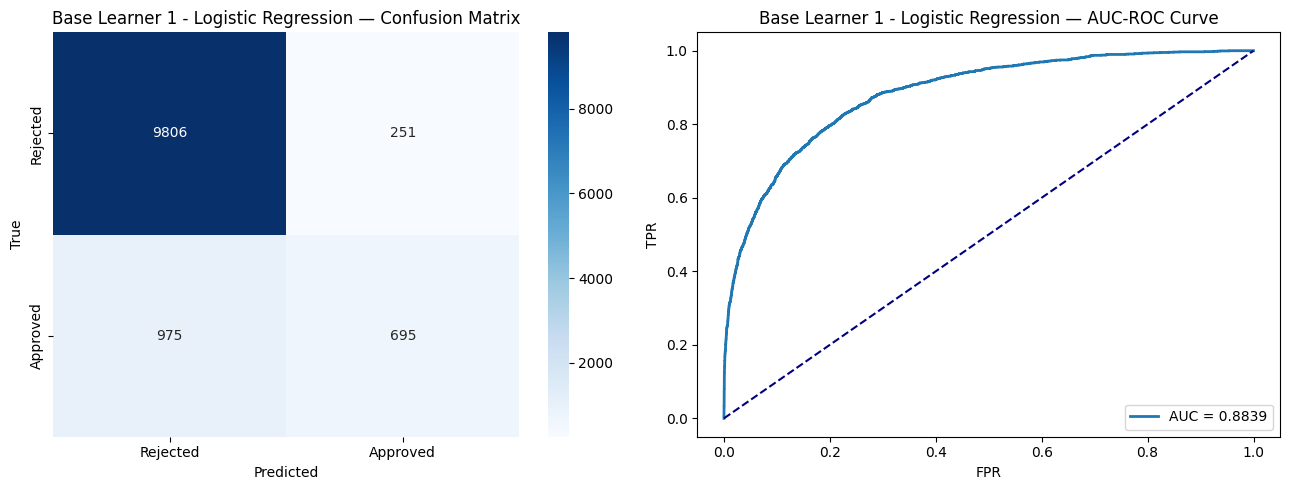

In [ ]:
# Initialise and train Base Learner 1: Logistic Regression
# Using best hyperparameters identified from "data_preprocessing" Notebook GridSearchCV
lr_base = LogisticRegression(max_iter=1000, random_state=SEED, C=1, penalty='l2', solver='saga')
lr_base.fit(X_train_c, y_train_c)

# Evaluate Logistic Regression base learner on test set
lr_base_results = evaluate_classifier(lr_base, X_test_c, y_test_c, 'Base Learner 1 - Logistic Regression')


========== Base Learner 2 - Naive Bayes ==========
Accuracy: 0.8218 | Recall: 0.8358 | Precision: 0.9504 | F1: 0.8894 | AUC: 0.8675
              precision    recall  f1-score   support

Rejected (0)       0.95      0.84      0.89     10057
Approved (1)       0.43      0.74      0.54      1670

    accuracy                           0.82     11727
   macro avg       0.69      0.79      0.72     11727
weighted avg       0.88      0.82      0.84     11727



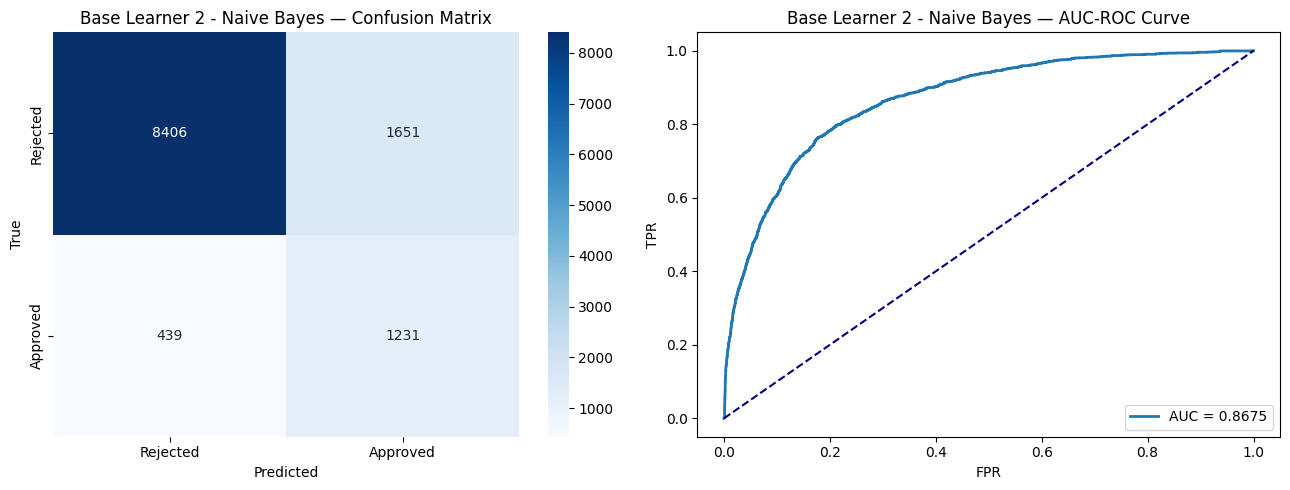

In [6]:
# Initialise and train Base Learner 2: Naive Bayes
nb_base = GaussianNB()
nb_base.fit(X_train_c, y_train_c)

# Evaluate Naive Bayes base learner on test set
nb_base_results = evaluate_classifier(nb_base, X_test_c, y_test_c, 'Base Learner 2 - Naive Bayes')

## Build and Evaluate Probability-Based Voting Ensemble Classifier


========== Voting Ensemble Classifier (LR + NB) ==========
Accuracy: 0.8633 | Recall: 0.9012 | Precision: 0.9370 | F1: 0.9187 | AUC: 0.8819
              precision    recall  f1-score   support

Rejected (0)       0.94      0.90      0.92     10057
Approved (1)       0.52      0.64      0.57      1670

    accuracy                           0.86     11727
   macro avg       0.73      0.77      0.74     11727
weighted avg       0.88      0.86      0.87     11727



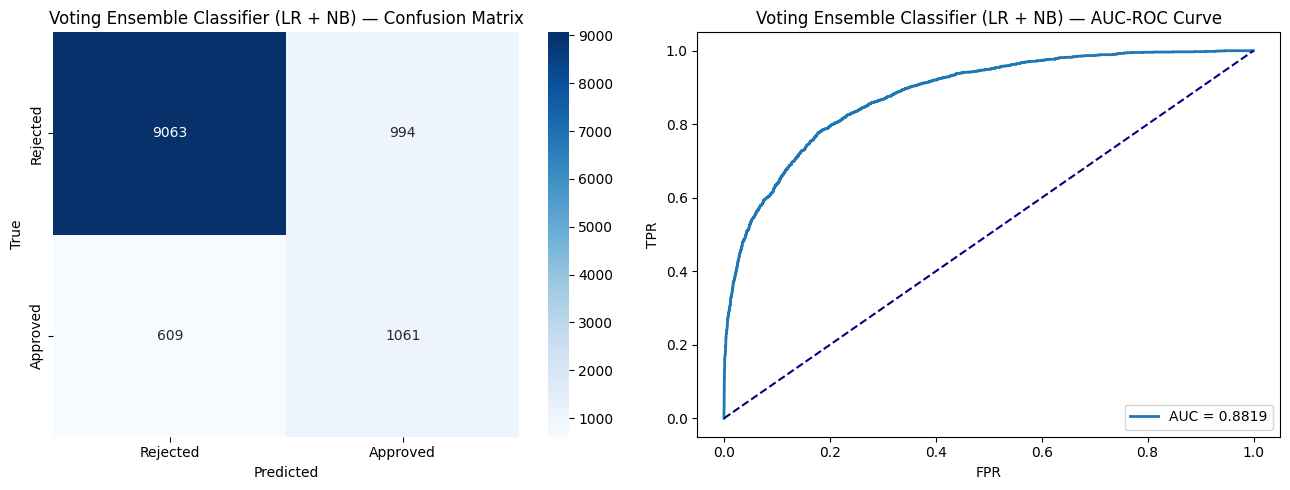

In [7]:
# Declare the two base learner objects for the ensemble
base_lr = LogisticRegression(max_iter=1000, random_state=SEED, C=1, penalty='l2', solver='saga')
base_nb = GaussianNB()

# Declare the VotingClassifier, combining Logistic Regression (LR) and Naive Bayes (NB) using soft (probability-based) voting.
# The 'voting='soft' parameter uses predicted probabilities and requires predict_proba from each base learner.
ensemble_model = VotingClassifier(
    estimators=[('lr', base_lr), ('nb', base_nb)],
    voting='soft'
)

# Fit (train) the ensemble classifier on the training data
ensemble_model.fit(X_train_c, y_train_c)

# Evaluate the Voting Ensemble Classifier on the test set
ensemble_results = evaluate_classifier(ensemble_model, X_test_c, y_test_c, 'Voting Ensemble Classifier (LR + NB)')

In [8]:
# Compare individual base learners versus the ensemble in a summary table
ensemble_summary = pd.DataFrame([lr_base_results, nb_base_results, ensemble_results])
print('\nEnsemble vs Base Learners — Summary Comparison:')
ensemble_summary.set_index('model')


Ensemble vs Base Learners — Summary Comparison:


,accuracy,recall,precision,f1,auc
model,,,,,
Base Learner 1 - Logistic Regression,0.895455,0.975042,0.909563,0.941165,0.883914
Base Learner 2 - Naive Bayes,0.821779,0.835836,0.950367,0.889430,0.867530
Voting Ensemble Classifier (LR + NB),0.863307,0.901163,0.937035,0.918749,0.881901


# PART B: Maximum Loan Amount — Decision Tree Regression
## Load Regression Dataset (Approved Clients Only)

In [ ]:
# Load the regression dataset (approved clients only) produced in "data_preprocessing" Notebook.
df_reg = pd.read_csv('cleaned_regression_data.csv')

# Display the dimensions and feature names of the regression dataset
print('Regression Dataset Shape:', df_reg.shape)
print('Feature Names:', df_reg.columns.tolist())

# Show first few rows of the dataset
df_reg.head()

Regression Dataset Shape: (8348, 12)
Feature Names: ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'loan_approval_status', 'max_allowed_loan']


,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,20.0,127000,MORTGAGE,2,DEBTCONSOLIDATION,24250,15.31,0.19,N,4,1,24250
1,20.0,95950,RENT,2,EDUCATION,28250,14.54,0.27,N,4,1,28250
2,20.0,59000,RENT,1,PERSONAL,16800,12.42,0.29,N,2,1,16800
3,21.0,30000,RENT,5,HOMEIMPROVEMENT,6500,14.27,0.22,N,4,1,6500
4,21.0,31000,RENT,5,EDUCATION,10000,11.49,0.32,N,2,1,10000


## Prepare Features and Target for Regression

In [10]:
# Separate features (X) and target variable (y) for regression
# Drop the target column and the classification label — not needed for regression
X_reg = df_reg.drop(columns=['max_allowed_loan', 'loan_approval_status'], errors='ignore')

# The target variable (y_reg) is the maximum loan amount offered to approved clients.
y_reg = df_reg['max_allowed_loan']

# Encode any categorical columns before training the Decision Tree
categorical_cols_reg = X_reg.select_dtypes(include=['object']).columns.tolist()
print('Categorical columns detected (regression):', categorical_cols_reg)
X_reg = pd.get_dummies(X_reg, columns=categorical_cols_reg, drop_first=True)

# Split regression data into 80% training and 20% test sets
# The 'random_state=SEED' parameter ensures reproducibility of the split.
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg,
    test_size=0.20,
    random_state=SEED
)

# Confirm the sizes of the training and test sets
print('Regression Training set:', X_train_r.shape)
print('Regression Test set:', X_test_r.shape)

Categorical columns detected (regression): ['home_ownership', 'loan_intent', 'payment_default_on_file']
Regression Training set: (6678, 16)
Regression Test set: (1670, 16)


## DT-1 — Fully Grown Decision Tree Regressor

In [11]:
# Declare DT-1: a fully grown (unpruned) Decision Tree Regressor
# No depth limit — grows until all leaves are pure or contain min_samples_split samples
dt1 = DecisionTreeRegressor(random_state=SEED)

# Fit DT-1 on the training data
dt1.fit(X_train_r, y_train_r)

# Display tree depth of the fully grown DT-1
print('DT-1 (Fully Grown) Tree Depth:', dt1.get_depth())
print('DT-1 Number of Leaves:', dt1.get_n_leaves())

DT-1 (Fully Grown) Tree Depth: 11
DT-1 Number of Leaves: 289


In [12]:
# 1. Ensure the feature names are grabbed from your main regression features
feature_cols = X_reg.columns.tolist()

# 2. Define Client 60256 exactly as per the report table
client_60256_data = {
    'age': [56],
    'income': [57000],
    'emplyment_length': [15],
    'loan_interest_rate': [23.0],
    'loan_income_ratio': [0.10],
    'credit_history_length': [35],
    'home_ownership_RENT': [1],
    'home_ownership_OWN': [0],
    'home_ownership_MORTGAGE': [0],
    'loan_intent_MEDICAL': [1],
    'loan_intent_EDUCATION': [0],
    'loan_intent_PERSONAL': [0],
    'loan_intent_VENTURE': [0],
    'loan_intent_HOMEIMPROVEMENT': [0],
    'loan_intent_DEBTCONSOLIDATION': [0]
}

# 3. Create the DataFrame for Client 60256 and enforcing the column order to match the model's training data.
client_60256_encoded = pd.DataFrame(client_60256_data)

# This line ensures that the column order of the client's data matches exactly what the trained model expects.
client_60256_encoded = client_60256_encoded.reindex(columns=feature_cols, fill_value=0)

# 4. Predict for Client 60256 using DT-1
predicted_max_loan_dt1 = dt1.predict(client_60256_encoded)

print(f'Client 60256 — Predicted Maximum Loan Amount (DT-1): £{predicted_max_loan_dt1[0]:,.2f}')

Client 60256 — Predicted Maximum Loan Amount (DT-1): £1,000.00


## DT-2 — Pruned Decision Tree Regressor
**Pruning method used:** Pre-pruning via `max_depth=4` (constraining tree depth before it is grown).

In [13]:
# Declare DT-2: a pruned Decision Tree Regressor limited to maximum depth of 4 levels
# The 'max_depth=4' parameter is a pre-pruning technique that limits tree growth before training.
dt2 = DecisionTreeRegressor(max_depth=4, random_state=SEED)

# Fit DT-2 on the training data
dt2.fit(X_train_r, y_train_r)

# Display tree depth of pruned DT-2
print('DT-2 (Pruned, max_depth=4) Tree Depth:', dt2.get_depth())
print('DT-2 Number of Leaves:', dt2.get_n_leaves())

DT-2 (Pruned, max_depth=4) Tree Depth: 4
DT-2 Number of Leaves: 16


##Visualise DT-1 and DT-2

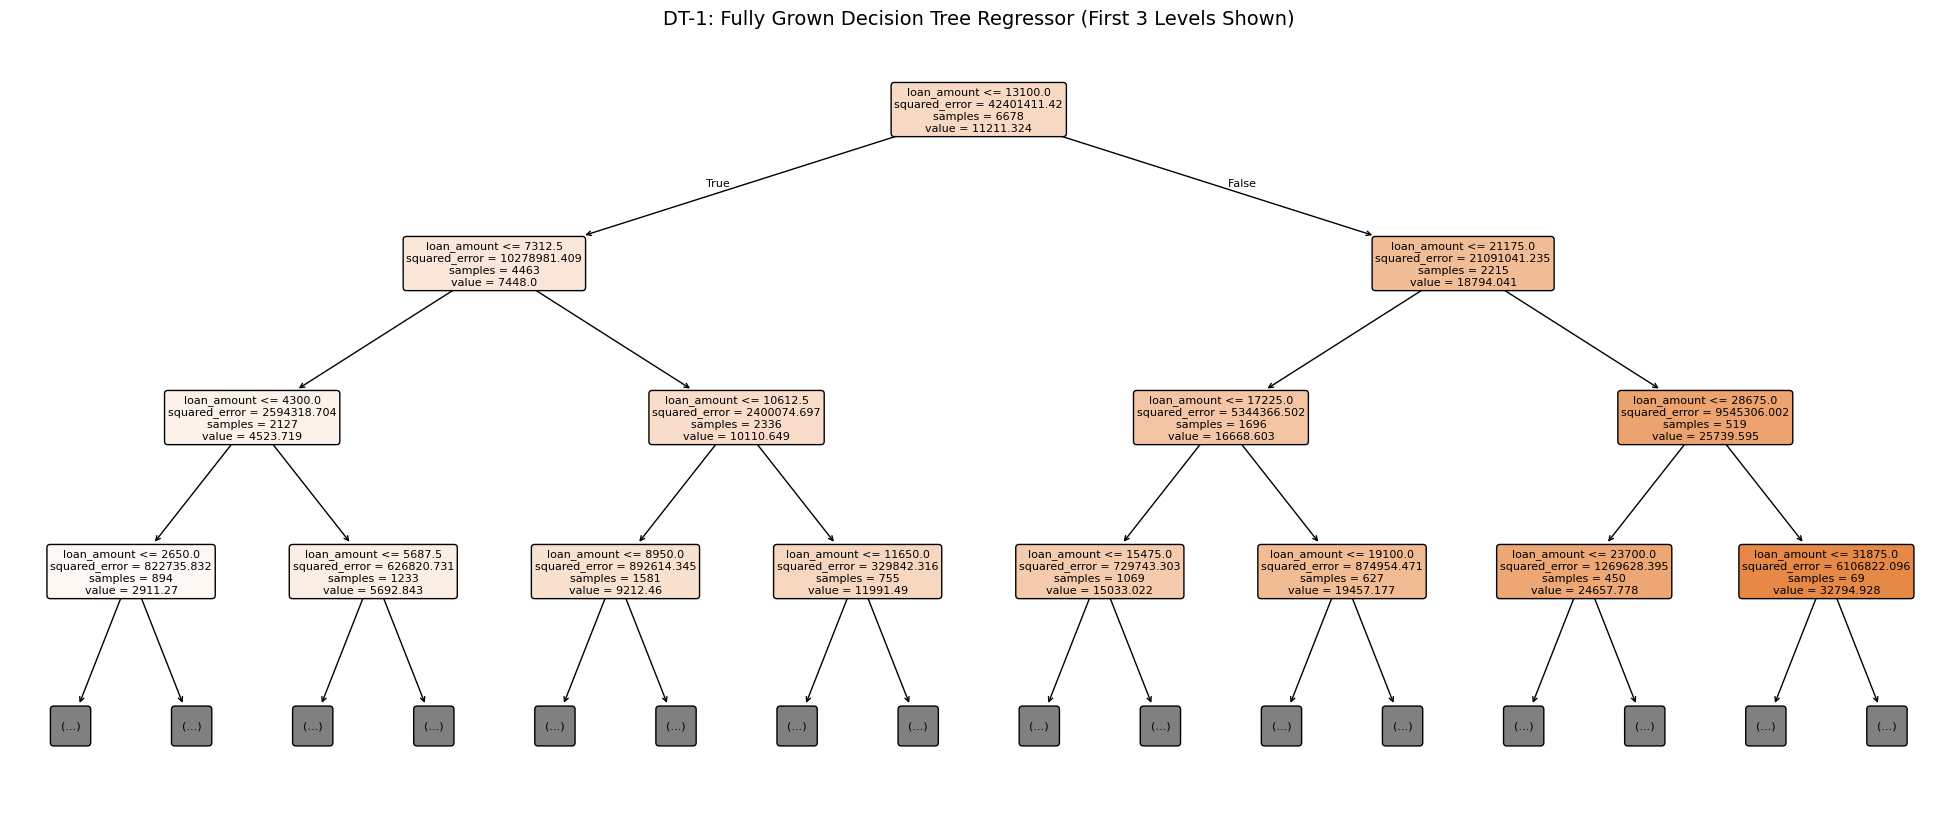

DT-1 saved as DT1_fully_grown.png


In [21]:
# Visualise DT-1: Fully Grown Decision Tree (truncated to depth 3 for readability)
plt.figure(figsize=(25, 10))
plot_tree(
    dt1,
    feature_names=X_reg.columns.tolist(),
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title('DT-1: Fully Grown Decision Tree Regressor (First 3 Levels Shown)', fontsize=14)
plt.savefig('DT1_fully_grown.png', dpi=150, bbox_inches='tight')
plt.show()
print('DT-1 saved as DT1_fully_grown.png')

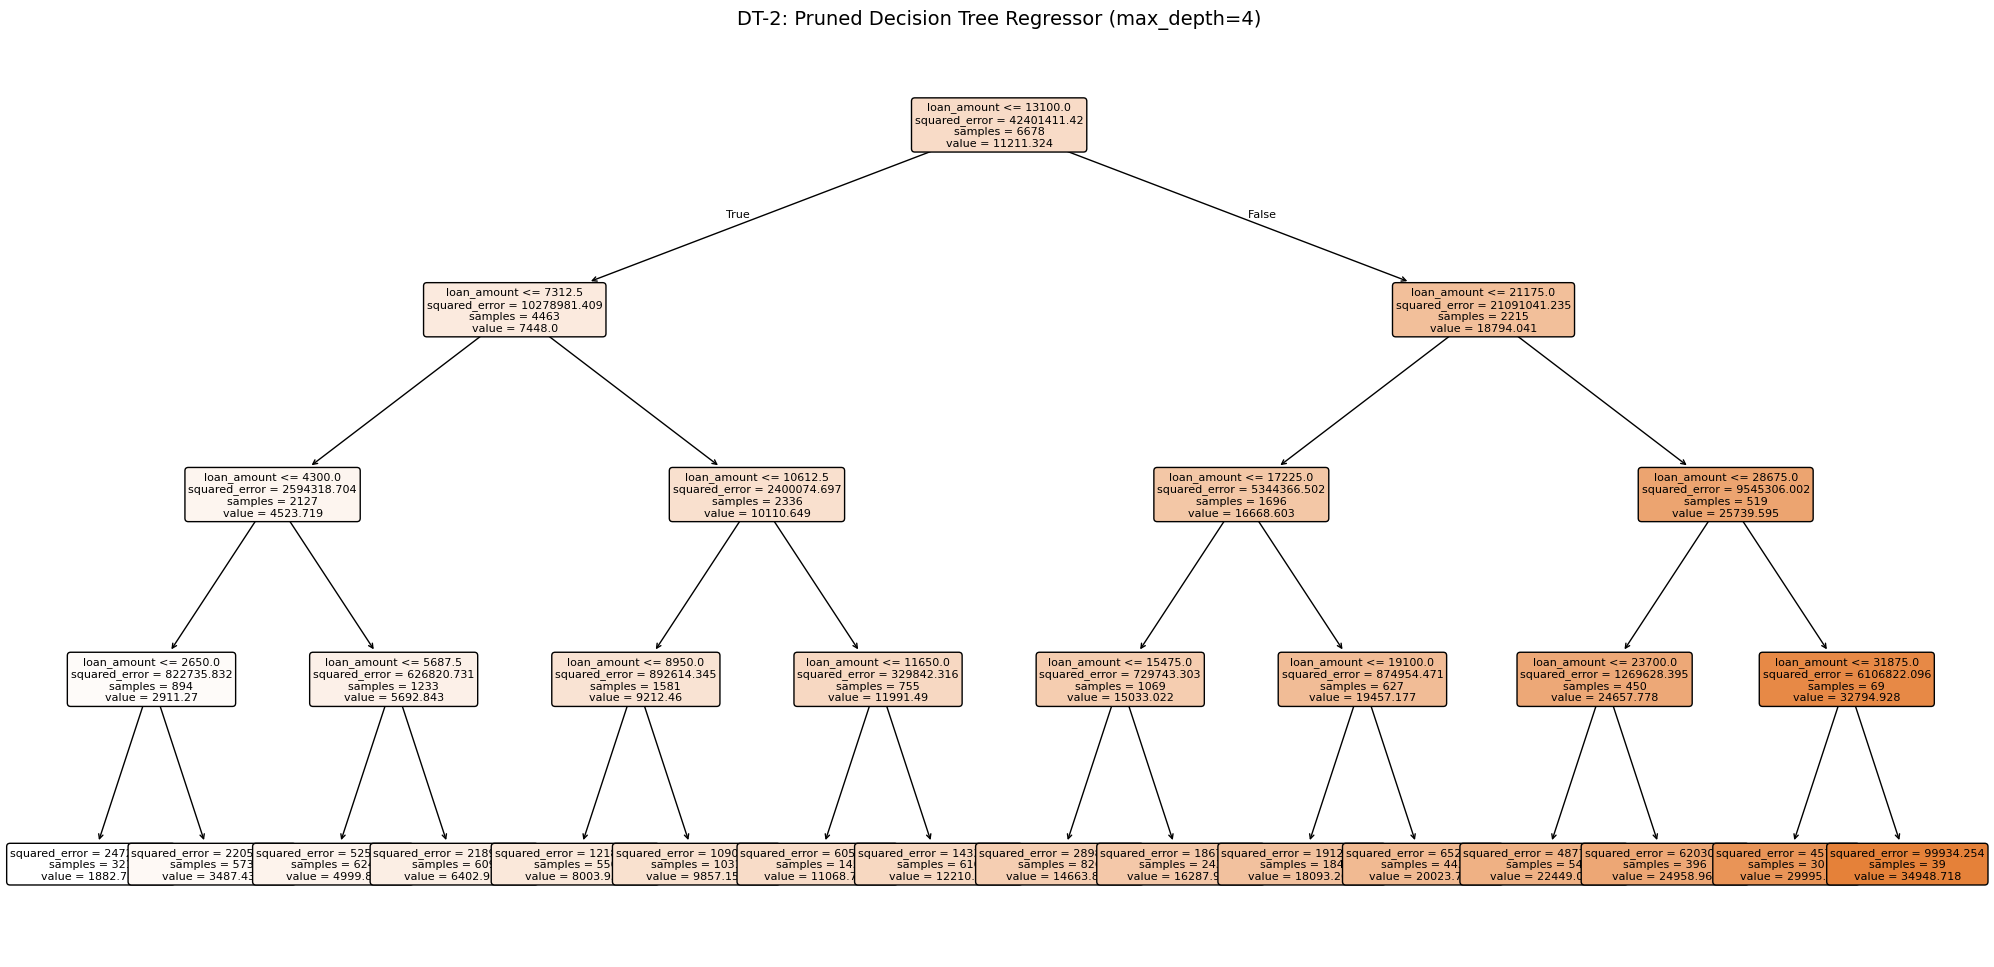

DT-2 saved as DT2_pruned.png


In [15]:
# Visualise DT-2: Pruned Decision Tree (max_depth=4 — full tree visible)
plt.figure(figsize=(25, 12))
plot_tree(
    dt2,
    feature_names=X_reg.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('DT-2: Pruned Decision Tree Regressor (max_depth=4)', fontsize=14)
plt.savefig('DT2_pruned.png', dpi=150, bbox_inches='tight')
plt.show()
print('DT-2 saved as DT2_pruned.png')

## Evaluate DT-1 and DT-2 Regression Models


In [16]:
# Predict Maximum Loan Amount on the test set using DT-1
y_pred_dt1 = dt1.predict(X_test_r)

# Predict Maximum Loan Amount on the test set using DT-2
y_pred_dt2 = dt2.predict(X_test_r)

# Calculate Mean Squared Error (MSE) for DT-1
mse_dt1 = mean_squared_error(y_test_r, y_pred_dt1)
# Calculate Mean Absolute Error (MAE) for DT-1
mae_dt1 = mean_absolute_error(y_test_r, y_pred_dt1)
# Calculate R-Squared (R²) value for DT-1
r2_dt1 = r2_score(y_test_r, y_pred_dt1)

# Calculate Mean Squared Error (MSE) for DT-2
mse_dt2 = mean_squared_error(y_test_r, y_pred_dt2)
# Calculate Mean Absolute Error (MAE) for DT-2
mae_dt2 = mean_absolute_error(y_test_r, y_pred_dt2)
# Calculate R-Squared (R²) value for DT-2
r2_dt2 = r2_score(y_test_r, y_pred_dt2)

# Print a header for the regression metrics summary table
print('Regression Metrics Summary:')
# Print the column headers for the table
print(f"{'Metric':<15} {'DT-1 (Fully Grown)':<25} {'DT-2 (Pruned)':<20}")
# Print a divider line for readability
print('-' * 60)
# Print the MSE scores for both models
print(f"{'MSE':<15} {mse_dt1:<25.2f} {mse_dt2:<20.2f}")
# Print the MAE scores for both models
print(f"{'MAE':<15} {mae_dt1:<25.2f} {mae_dt2:<20.2f}")
# Print the R-Squared scores for both models
print(f"{'R-Squared':<15} {r2_dt1:<25.4f} {r2_dt2:<20.4f}")

Regression Metrics Summary:
Metric          DT-1 (Fully Grown)        DT-2 (Pruned)       
------------------------------------------------------------
MSE             472.10                    176416.92           
MAE             2.23                      315.02              
R-Squared       1.0000                    0.9955              


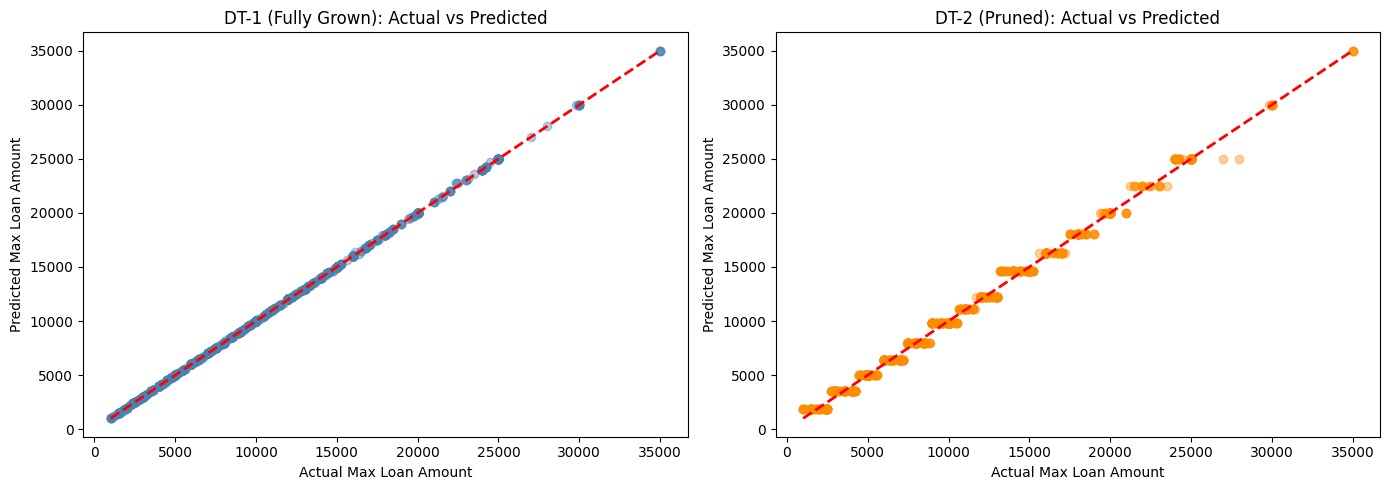

In [17]:
# Plot Actual vs Predicted values for both DT-1 and DT-2 to visualise prediction quality
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DT-1: Creating an Actual vs. Predicted scatter plot
axes[0].scatter(y_test_r, y_pred_dt1, alpha=0.4, color='steelblue')
axes[0].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
axes[0].set_title('DT-1 (Fully Grown): Actual vs Predicted')
axes[0].set_xlabel('Actual Max Loan Amount')
axes[0].set_ylabel('Predicted Max Loan Amount')

# DT-2: Creating an Actual vs. Predicted scatter plot
axes[1].scatter(y_test_r, y_pred_dt2, alpha=0.4, color='darkorange')
axes[1].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
axes[1].set_title('DT-2 (Pruned): Actual vs Predicted')
axes[1].set_xlabel('Actual Max Loan Amount')
axes[1].set_ylabel('Predicted Max Loan Amount')

plt.tight_layout()
plt.savefig('DT_Actual_vs_Predicted.png', dpi=150)
plt.show()

## Predict Maximum Loan Amount for Client 60256

Using the selected best-performing Decision Tree regression model, the system predicts the estimated maximum loan amount for Client 60256 based on their financial and credit-related attributes.

In [ ]:
# Construct the feature vector for Client 60256
# using the original client attributes from the dataset.
client_60256_raw = pd.DataFrame({
    'age': [56],
    'income': [57000],
    'home_ownership': ['RENT'],
    'emplyment_length': [15],
    'loan_intent': ['MEDICAL'],
    'loan_amount': [25700],
    'loan_interest_rate': [23.0],
    'loan_income_ratio': [0.10],
    'payment_default_on_file': ['N'],
    'credit_history_length': [35]
})

# Apply the same one-hot encoding used during the model training phase
# Reindex the encoded client data to match the training columns exactly, filling any missing dummy variables with 0
client_60256_encoded = pd.get_dummies(client_60256_raw)
client_60256_encoded = client_60256_encoded.reindex(columns=X_reg.columns, fill_value=0)

# Predict using DT-2 (pruned model — generally better generalisation)
# NOTE: Change to dt1 if your analysis determined DT-1 was the better model
predicted_max_loan = dt2.predict(client_60256_encoded)

print(f'Client 60256 — Predicted Maximum Loan Amount (DT-2 Pruned): £{predicted_max_loan[0]:,.2f}')

Client 60256 — Predicted Maximum Loan Amount (DT-2 Pruned): £24,958.96


In [19]:
# Show the decision path taken by DT-2 for Client 60256
# This shows which nodes were traversed within the decision tree to arrive at the prediction
node_indicator = dt2.decision_path(client_60256_encoded)
leaf_id = dt2.apply(client_60256_encoded)

# Print the node IDs traversed in the decision path
print('Decision path node IDs for Client 60256:')
print(node_indicator.indices)
print('Leaf node reached:', leaf_id[0])

# Print the feature and threshold at each decision node along the path
feature = dt2.tree_.feature
threshold = dt2.tree_.threshold
feature_names = X_reg.columns.tolist()

# Print a header for the decision path explanation
print('\nDecision path explanation for Client 60256:')

# Iterating through each node index in the decision path, excluding the final leaf node
for node_id in node_indicator.indices[:-1]:
    # Get the name of the feature evaluated at the current node
    feat = feature_names[feature[node_id]]
    # Get the threshold value used for the split at the current node
    thresh = threshold[node_id]
    # Extract the client's actual value for this specific feature
    client_val = client_60256_encoded.iloc[0][feat]
    # Determine the direction of the split based on the client's feature value
    direction = '<=' if client_val <= thresh else '>'
    # Print the logical step taken by the decision tree at this node
    print(f'  Node {node_id}: {feat} = {client_val} {direction} {thresh:.4f}')

Decision path node IDs for Client 60256:
[ 0 16 24 25 27]
Leaf node reached: 27

Decision path explanation for Client 60256:
  Node 0: loan_amount = 25700 > 13100.0000
  Node 16: loan_amount = 25700 > 21175.0000
  Node 24: loan_amount = 25700 <= 28675.0000
  Node 25: loan_amount = 25700 > 23700.0000
